<a href="https://colab.research.google.com/github/hiranyahp/Emotional-face-detection-CNN-colab-code/blob/main/Emotional_face_detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# CELL 1: Install required packages



!pip install -q timm opencv-python web3 scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.5/587.5 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.3/340.3 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 113.9 MB/s eta 0:00:00


In [ ]:

# CELL 2: Imports, Google Drive mount, exact dataset paths,
# device setup, and training configuration


import os
import cv2
import json
import time
import math
import copy
import glob
import hashlib
import random
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler, Subset
from torchvision import datasets, transforms, models

warnings.filterwarnings("ignore")


# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)


# Reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# Device configuration

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))




# MyDrive / emotion detection data / train, test

BASE_DIR = "/content/drive/MyDrive/emotion detection data"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")


# Path checks

print("\n================ PATH CHECK ================\n")
print("BASE_DIR:", BASE_DIR)
print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))

# Show folder contents for debugging
if os.path.exists("/content/drive/MyDrive"):
    print("\nFolders in MyDrive:")
    print(os.listdir("/content/drive/MyDrive"))

if os.path.exists(BASE_DIR):
    print("\nFolders inside BASE_DIR:")
    print(os.listdir(BASE_DIR))

if os.path.exists(TRAIN_DIR):
    train_classes = sorted([
        d for d in os.listdir(TRAIN_DIR)
        if os.path.isdir(os.path.join(TRAIN_DIR, d))
    ])
    print("\nTrain class folders:")
    print(train_classes)

    print("\nTraining image count per class:")
    for cls in train_classes:
        cls_path = os.path.join(TRAIN_DIR, cls)
        count = len([
            f for f in os.listdir(cls_path)
            if os.path.isfile(os.path.join(cls_path, f))
        ])
        print(f"{cls}: {count}")
else:
    print("\nTRAIN_DIR was not found.")

if os.path.exists(TEST_DIR):
    test_classes = sorted([
        d for d in os.listdir(TEST_DIR)
        if os.path.isdir(os.path.join(TEST_DIR, d))
    ])
    print("\nTest class folders:")
    print(test_classes)

    print("\nTest image count per class:")
    for cls in test_classes:
        cls_path = os.path.join(TEST_DIR, cls)
        count = len([
            f for f in os.listdir(cls_path)
            if os.path.isfile(os.path.join(cls_path, f))
        ])
        print(f"{cls}: {count}")
else:
    print("\nTEST_DIR was not found.")

# Image and training settings

IMG_SIZE = 224
BATCH_SIZE = 128
NUM_WORKERS = 2
VAL_SPLIT = 0.2
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.4
PATIENCE = 6


# Save paths

SAVE_DIR = "/content/drive/MyDrive/emotion_project_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_emotion_model.pth")
LAST_MODEL_PATH = os.path.join(SAVE_DIR, "last_emotion_model.pth")
CLASS_NAMES_PATH = os.path.join(SAVE_DIR, "class_names.json")
TRAIN_HISTORY_PATH = os.path.join(SAVE_DIR, "train_history.json")


# Final safety check

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(
        f"TRAIN_DIR not found: {TRAIN_DIR}\n"
        f"Please confirm the folder is exactly inside MyDrive and named correctly."
    )

if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(
        f"TEST_DIR not found: {TEST_DIR}\n"
        f"Please confirm the folder is exactly inside MyDrive and named correctly."
    )

print("\nDataset path is correct and ready for the next cells.")

Mounted at /content/drive
Using device: cuda
GPU Name: NVIDIA A100-SXM4-80GB

================ PATH CHECK ================

BASE_DIR: /content/drive/MyDrive/emotion detection data
Train dir exists: True
Test dir exists: True

Folders in MyDrive:
['1Password Emergency Kit A3-4TMCBA-my.pdf', 'Hiranaya Premaratne Cv.pdf', 'Screenshot 2026-01-14 110642.png', 'Screenshot 2026-01-14 114205.png', 'Screenshot 2026-01-14 160624.png', 'Screenshot 2026-01-14 160901.png', 'Screenshot 2026-01-14 211542.png', 'Screenshot 2026-01-14 212500.png', 'Screenshot 2026-01-14 212918.png', 'Screenshot 2026-01-14 214146.png', 'Screenshot 2026-01-14 230125.png', 'Screenshot 2026-01-14 230703.png', 'Screenshot 2026-01-14 231232.png', 'Screenshot 2026-01-16 123042.png', 'Screenshot 2026-01-16 123740.png', 'Screenshot 2026-01-16 124358.png', 'Screenshot 2026-01-16 124741.png', 'Screenshot 2026-01-16 145613.png', 'Screenshot 2026-01-16 155529.png', 'Screenshot 2026-01-17 200528.png', 'Screenshot 2026-01-17 204138.p

In [ ]:

# CELL 2: Imports, Google Drive mount, exact dataset paths,
# device setup, and training configuration


import os
import cv2
import json
import time
import math
import copy
import glob
import hashlib
import random
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler, Subset
from torchvision import datasets, transforms, models

warnings.filterwarnings("ignore")


# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# Device configuration

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))



# MyDrive / emotion detection data / train, test

BASE_DIR = "/content/drive/MyDrive/emotion detection data"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")


# Path checks

print("\n================ PATH CHECK ================\n")
print("BASE_DIR:", BASE_DIR)
print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))

# Show folder contents for debugging
if os.path.exists("/content/drive/MyDrive"):
    print("\nFolders in MyDrive:")
    print(os.listdir("/content/drive/MyDrive"))

if os.path.exists(BASE_DIR):
    print("\nFolders inside BASE_DIR:")
    print(os.listdir(BASE_DIR))

if os.path.exists(TRAIN_DIR):
    train_classes = sorted([
        d for d in os.listdir(TRAIN_DIR)
        if os.path.isdir(os.path.join(TRAIN_DIR, d))
    ])
    print("\nTrain class folders:")
    print(train_classes)

    print("\nTraining image count per class:")
    for cls in train_classes:
        cls_path = os.path.join(TRAIN_DIR, cls)
        count = len([
            f for f in os.listdir(cls_path)
            if os.path.isfile(os.path.join(cls_path, f))
        ])
        print(f"{cls}: {count}")
else:
    print("\nTRAIN_DIR was not found.")

if os.path.exists(TEST_DIR):
    test_classes = sorted([
        d for d in os.listdir(TEST_DIR)
        if os.path.isdir(os.path.join(TEST_DIR, d))
    ])
    print("\nTest class folders:")
    print(test_classes)

    print("\nTest image count per class:")
    for cls in test_classes:
        cls_path = os.path.join(TEST_DIR, cls)
        count = len([
            f for f in os.listdir(cls_path)
            if os.path.isfile(os.path.join(cls_path, f))
        ])
        print(f"{cls}: {count}")
else:
    print("\nTEST_DIR was not found.")


# Image and training settings

IMG_SIZE = 224
BATCH_SIZE = 128
NUM_WORKERS = 2
VAL_SPLIT = 0.2
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.4
PATIENCE = 6


# Save paths

SAVE_DIR = "/content/drive/MyDrive/emotion_project_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_emotion_model.pth")
LAST_MODEL_PATH = os.path.join(SAVE_DIR, "last_emotion_model.pth")
CLASS_NAMES_PATH = os.path.join(SAVE_DIR, "class_names.json")
TRAIN_HISTORY_PATH = os.path.join(SAVE_DIR, "train_history.json")


# Final safety check

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(
        f"TRAIN_DIR not found: {TRAIN_DIR}\n"
        f"Please confirm the folder is exactly inside MyDrive and named correctly."
    )

if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(
        f"TEST_DIR not found: {TEST_DIR}\n"
        f"Please confirm the folder is exactly inside MyDrive and named correctly."
    )

print("\nDataset path is correct and ready for the next cells.")

Mounted at /content/drive
Using device: cuda
GPU Name: NVIDIA A100-SXM4-80GB

================ PATH CHECK ================

BASE_DIR: /content/drive/MyDrive/emotion detection data
Train dir exists: True
Test dir exists: True

Folders in MyDrive:
['1Password Emergency Kit A3-4TMCBA-my.pdf', 'Hiranaya Premaratne Cv.pdf', 'Screenshot 2026-01-14 110642.png', 'Screenshot 2026-01-14 114205.png', 'Screenshot 2026-01-14 160624.png', 'Screenshot 2026-01-14 160901.png', 'Screenshot 2026-01-14 211542.png', 'Screenshot 2026-01-14 212500.png', 'Screenshot 2026-01-14 212918.png', 'Screenshot 2026-01-14 214146.png', 'Screenshot 2026-01-14 230125.png', 'Screenshot 2026-01-14 230703.png', 'Screenshot 2026-01-14 231232.png', 'Screenshot 2026-01-16 123042.png', 'Screenshot 2026-01-16 123740.png', 'Screenshot 2026-01-16 124358.png', 'Screenshot 2026-01-16 124741.png', 'Screenshot 2026-01-16 145613.png', 'Screenshot 2026-01-16 155529.png', 'Screenshot 2026-01-17 200528.png', 'Screenshot 2026-01-17 204138.p

In [ ]:

# CELL 4: Image transforms
# FER images are grayscale, but pretrained CNN models expect
# 3 channels. So grayscale is converted to 3 channels.


train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully.")

Transforms created successfully.


In [ ]:

# CELL 4: Image transforms
# FER images are grayscale, but pretrained CNN models expect
# 3 channels. So grayscale is converted to 3 channels.


train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully.")

Transforms created successfully.


In [ ]:

# CELL 5: Create datasets
# create:
# 1. Full training dataset
# 2. Validation split from training data
# 3. Test dataset


full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
full_train_dataset_for_val = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

# Save class names for later inference / UI
with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f)

# Split train dataset into train and validation
train_size = int((1 - VAL_SPLIT) * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

train_subset_idx, val_subset_idx = random_split(
    range(len(full_train_dataset)),
    [train_size, val_size],
    generator=generator
)

train_indices = train_subset_idx.indices
val_indices = val_subset_idx.indices

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_train_dataset_for_val, val_indices)

print("Train samples     :", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples      :", len(test_dataset))

Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7
Train samples     : 22989
Validation samples: 5748
Test samples      : 7178


In [ ]:

# CELL 6: Handle class imbalance
# use:
# 1. class weights in the loss function
# 2. weighted sampling for the training loader


train_targets_all = np.array(full_train_dataset.targets)
train_targets = train_targets_all[train_indices]

classes_np = np.unique(train_targets)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_np,
    y=train_targets
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class weights:")
for cls_name, weight in zip(class_names, class_weights):
    print(f"{cls_name}: {weight:.4f}")


sample_weights = class_weights[train_targets]
sample_weights = torch.from_numpy(sample_weights).double()

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Class imbalance handling is ready.")

Class weights:
angry: 1.0241
disgust: 9.3035
fear: 1.0000
happy: 0.5671
neutral: 0.8252
sad: 0.8546
surprise: 1.2976
Class imbalance handling is ready.


In [ ]:

# CELL 7: Create dataloaders


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Dataloaders created successfully.")

Dataloaders created successfully.


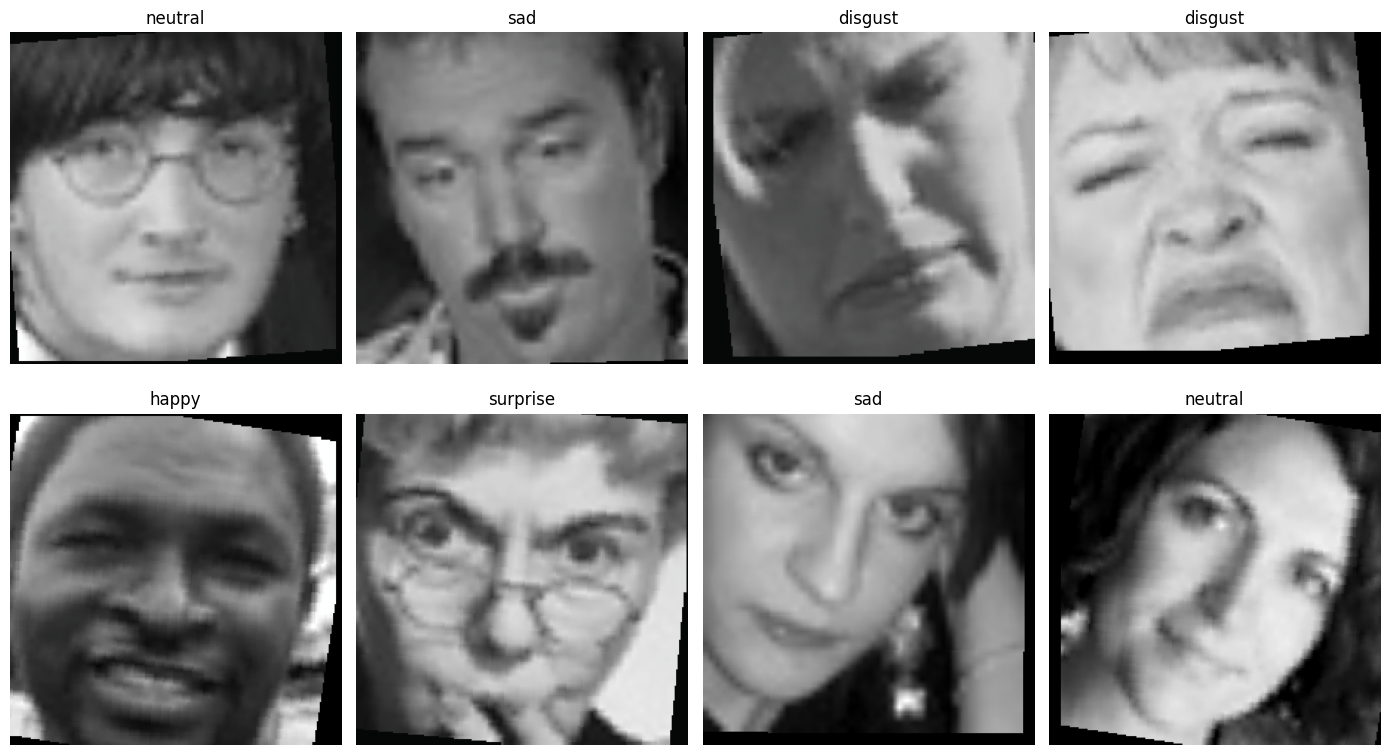

In [ ]:

# CELL 8: Visualize sample images
# helps verify preprocessing and augmentation.

def imshow_tensor(img_tensor, title=None):
    img = img_tensor.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis("off")

images, labels = next(iter(train_loader))

plt.figure(figsize=(14, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    imshow_tensor(images[i], title=class_names[labels[i].item()])
plt.tight_layout()
plt.show()

In [ ]:

# CELL 9: Define CNN-based emotion detection model
# use pretrained ResNet18 because:
# - it is a CNN
# - strong for image classification
# - practical for FER tasks
# - good for your research implementation
#
# ReLU is included in ResNet internally, also add an
# explicit ReLU in the final classifier head.


class EmotionResNet(nn.Module):
    def __init__(self, num_classes=7, dropout=DROPOUT):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = EmotionResNet(num_classes=num_classes).to(DEVICE)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 226MB/s]

EmotionResNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [ ]:

# CELL 10: Loss function, optimizer, and scheduler


criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Loss, optimizer, and scheduler are ready.")

Loss, optimizer, and scheduler are ready.


In [ ]:

# CELL 11: Training and evaluation functions


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

print("Training functions are ready.")

Training functions are ready.


In [ ]:

# CELL 12: Training loop with early stopping and model saving


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_epoch = 0
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    torch.save({
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "img_size": IMG_SIZE
    }, LAST_MODEL_PATH)


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_model_wts = copy.deepcopy(model.state_dict())

        torch.save({
            "model_state_dict": best_model_wts,
            "class_names": class_names,
            "img_size": IMG_SIZE
        }, BEST_MODEL_PATH)

        print("Best model saved.")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

end_time = time.time()
training_minutes = (end_time - start_time) / 60

# Load best weights back into model
model.load_state_dict(best_model_wts)

# Save training history
with open(TRAIN_HISTORY_PATH, "w") as f:
    json.dump(history, f)

print("\nTraining complete.")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Epoch: {best_epoch}")
print(f"Training Time: {training_minutes:.2f} minutes")
print("Best model saved at:", BEST_MODEL_PATH)


Epoch [1/25]
Train Loss: 0.9194 | Train Acc: 0.3138
Val   Loss: 1.3502 | Val   Acc: 0.4725
Best model saved.

Epoch [2/25]
Train Loss: 0.5618 | Train Acc: 0.5467
Val   Loss: 1.1283 | Val   Acc: 0.5611
Best model saved.

Epoch [3/25]
Train Loss: 0.4554 | Train Acc: 0.6201
Val   Loss: 1.1422 | Val   Acc: 0.5637
Best model saved.

Epoch [4/25]
Train Loss: 0.4349 | Train Acc: 0.6451
Val   Loss: 1.0698 | Val   Acc: 0.6209
Best model saved.

Epoch [5/25]
Train Loss: 0.4033 | Train Acc: 0.6738
Val   Loss: 1.0522 | Val   Acc: 0.6261
Best model saved.

Epoch [6/25]
Train Loss: 0.3608 | Train Acc: 0.6998
Val   Loss: 1.1018 | Val   Acc: 0.6256
No improvement. Patience: 1/6

Epoch [7/25]
Train Loss: 0.3425 | Train Acc: 0.7211
Val   Loss: 1.0660 | Val   Acc: 0.6461
Best model saved.

Epoch [8/25]
Train Loss: 0.3032 | Train Acc: 0.7454
Val   Loss: 1.1020 | Val   Acc: 0.6543
Best model saved.

Epoch [9/25]
Train Loss: 0.2974 | Train Acc: 0.7481
Val   Loss: 1.0907 | Val   Acc: 0.6571
Best model saved

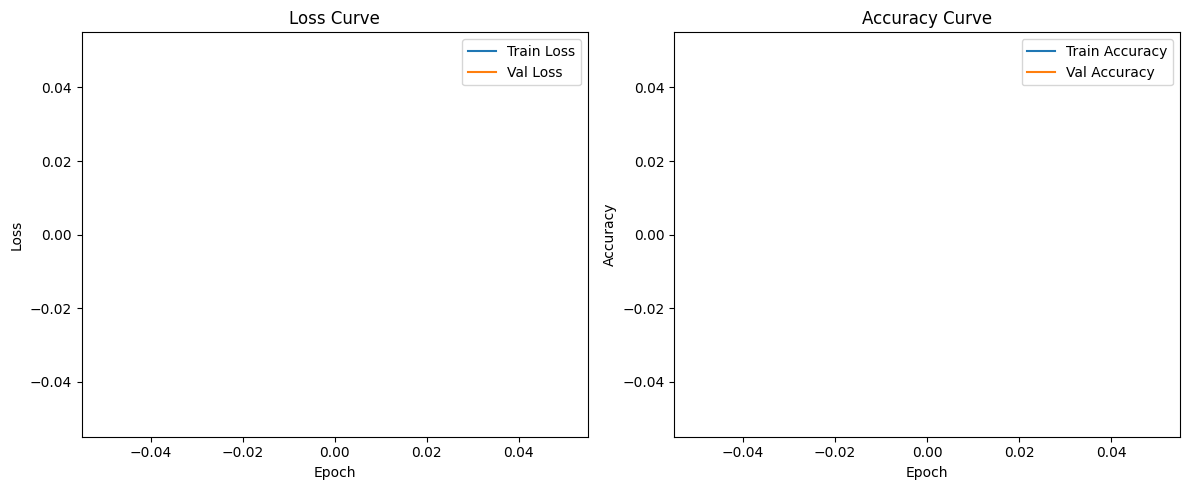

In [ ]:

# CELL 13: Plot training and validation curves


epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:

# CELL 14: Evaluate the trained model on the test set


test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, DEVICE)

print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Test Loss    : 1.2959
Test Accuracy: 0.6687

Classification Report:

              precision    recall  f1-score   support

       angry     0.5601    0.6326    0.5941       958
     disgust     0.8537    0.6306    0.7254       111
        fear     0.5504    0.4961    0.5218      1024
       happy     0.8919    0.8230    0.8561      1774
     neutral     0.6096    0.6383    0.6236      1233
         sad     0.5327    0.5485    0.5405      1247
    surprise     0.7793    0.8243    0.8012       831

    accuracy                         0.6687      7178
   macro avg     0.6825    0.6562    0.6661      7178
weighted avg     0.6744    0.6687    0.6703      7178



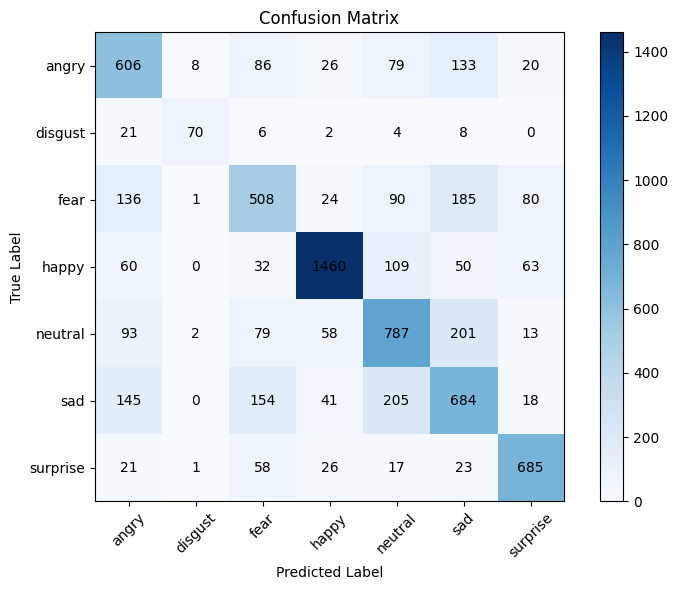

In [ ]:

# CELL 15: Confusion matrix


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"), ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [ ]:

# CELL 16: Predict emotion from a single image


def predict_image(image_path, model, class_names, transform, device):
    model.eval()

    image = Image.open(image_path).convert("L")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = class_names[pred_idx]
        confidence = probs[0, pred_idx].item()

    return pred_label, confidence



In [ ]:

# CELL 17: Save all important artifacts in one ZIP file
# helps later when building the UI.


artifact_zip_path = os.path.join(SAVE_DIR, "emotion_model_artifacts.zip")

import zipfile

with zipfile.ZipFile(artifact_zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(BEST_MODEL_PATH, arcname="best_emotion_model.pth")
    zf.write(LAST_MODEL_PATH, arcname="last_emotion_model.pth")
    zf.write(CLASS_NAMES_PATH, arcname="class_names.json")
    zf.write(TRAIN_HISTORY_PATH, arcname="train_history.json")

print("Artifact ZIP created successfully:")
print(artifact_zip_path)

Artifact ZIP created successfully:
/content/drive/MyDrive/emotion_project_artifacts/emotion_model_artifacts.zip


In [ ]:

# CELL 18: Simple privacy-preserving blockchain logger
#
# IMPORTANT:
# This does NOT store facial images.
# It stores only:
# - predicted emotion label
# - timestamp
# - hashed subject/session/frame identifier
#
# This supports privacy preservation in your proposal.


class SimpleEmotionBlockchain:
    def __init__(self):
        self.chain = []
        self.create_genesis_block()

    def create_genesis_block(self):
        genesis_block = {
            "index": 0,
            "timestamp": str(datetime.utcnow()),
            "emotion": "GENESIS",
            "subject_hash": "0",
            "prev_hash": "0",
            "block_hash": "0"
        }
        self.chain.append(genesis_block)

    def calculate_hash(self, block):
        block_string = json.dumps({
            "index": block["index"],
            "timestamp": block["timestamp"],
            "emotion": block["emotion"],
            "subject_hash": block["subject_hash"],
            "prev_hash": block["prev_hash"]
        }, sort_keys=True).encode()
        return hashlib.sha256(block_string).hexdigest()

    def add_emotion_log(self, emotion_label, subject_identifier):
        subject_hash = hashlib.sha256(str(subject_identifier).encode()).hexdigest()

        new_block = {
            "index": len(self.chain),
            "timestamp": str(datetime.utcnow()),
            "emotion": emotion_label,
            "subject_hash": subject_hash,
            "prev_hash": self.chain[-1]["block_hash"]
        }

        new_block["block_hash"] = self.calculate_hash(new_block)
        self.chain.append(new_block)

    def is_chain_valid(self):
        for i in range(1, len(self.chain)):
            current = self.chain[i]
            previous = self.chain[i - 1]

            if current["block_hash"] != self.calculate_hash(current):
                return False

            if current["prev_hash"] != previous["block_hash"]:
                return False

        return True

    def save_chain(self, path):
        with open(path, "w") as f:
            json.dump(self.chain, f, indent=4)
        print("Blockchain log saved to:", path)

#blockchain usage
emotion_chain = SimpleEmotionBlockchain()
emotion_chain.add_emotion_log("happy", "session_001_frame_001")
emotion_chain.add_emotion_log("sad", "session_001_frame_002")

print("Blockchain valid:", emotion_chain.is_chain_valid())

BLOCKCHAIN_LOG_PATH = os.path.join(SAVE_DIR, "emotion_blockchain_log.json")
emotion_chain.save_chain(BLOCKCHAIN_LOG_PATH)

Blockchain valid: True
Blockchain log saved to: /content/drive/MyDrive/emotion_project_artifacts/emotion_blockchain_log.json


In [ ]:

# CELL 19: Load the saved model later for UI / inference


def load_saved_model(model_path, device):
    checkpoint = torch.load(model_path, map_location=device)

    loaded_class_names = checkpoint["class_names"]
    loaded_model = EmotionResNet(num_classes=len(loaded_class_names))
    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()

    return loaded_model, loaded_class_names

loaded_model, loaded_class_names = load_saved_model(BEST_MODEL_PATH, DEVICE)

print("Loaded model successfully.")
print("Loaded class names:", loaded_class_names)

Loaded model successfully.
Loaded class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:

# CELL 20: OpenCV face detection and face emotion prediction
# These functions are useful for webcam/video-based inference.


face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def preprocess_face(face_bgr, img_size=IMG_SIZE):
    face_gray = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
    pil_img = Image.fromarray(face_gray)
    tensor = eval_transform(pil_img).unsqueeze(0)
    return tensor

def predict_face(face_bgr, model, class_names, device):
    model.eval()
    tensor = preprocess_face(face_bgr).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = class_names[pred_idx]
        confidence = probs[0, pred_idx].item()

    return pred_label, confidence

print("OpenCV helper functions are ready.")

OpenCV helper functions are ready.


In [ ]:

# CELL 21: Process a saved video file

# It detects faces, predicts emotion, and writes output video.
# It can also log emotion labels into the blockchain logger.


def process_video_file(input_video_path, output_video_path, model, class_names, blockchain_logger=None):
    cap = cv2.VideoCapture(input_video_path)

    if not cap.isOpened():
        print("Could not open input video.")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    last_log_time = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_detector.detectMultiScale(
            gray,
            scaleFactor=1.2,
            minNeighbors=5,
            minSize=(48, 48)
        )

        for i, (x, y, w, h) in enumerate(faces):
            face_roi = frame[y:y+h, x:x+w]

            try:
                label, conf = predict_face(face_roi, model, class_names, DEVICE)
                text = f"{label} ({conf:.2f})"

                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(
                    frame,
                    text,
                    (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (0, 255, 0),
                    2
                )

                current_time = time.time()
                if blockchain_logger is not None and (current_time - last_log_time) >= 3:
                    session_identifier = f"video_face_{i}_{int(current_time)}"
                    blockchain_logger.add_emotion_log(label, session_identifier)
                    last_log_time = current_time

            except Exception as e:
                print("Prediction error:", e)

        writer.write(frame)

    cap.release()
    writer.release()

    if blockchain_logger is not None:
        video_blockchain_path = os.path.join(SAVE_DIR, "video_emotion_blockchain.json")
        blockchain_logger.save_chain(video_blockchain_path)

    print("Processed video saved to:", output_video_path)

In [ ]:

# CELL 22: Example usage for saved video inference
# Put your own input video path from Google Drive.


# Example paths:
# INPUT_VIDEO_PATH = "/content/drive/MyDrive/input_video.mp4"
# OUTPUT_VIDEO_PATH = "/content/drive/MyDrive/output_emotion_video.mp4"

# emotion_chain_video = SimpleEmotionBlockchain()

# process_video_file(
#     input_video_path=INPUT_VIDEO_PATH,
#     output_video_path=OUTPUT_VIDEO_PATH,
#     model=loaded_model,
#     class_names=loaded_class_names,
#     blockchain_logger=emotion_chain_video
# )

print("Video inference example cell is ready. Uncomment and set paths when needed.")

Video inference example cell is ready. Uncomment and set paths when needed.


In [ ]:

# SAVE MODEL MANUALLY (without retraining)


import torch
import json
import os


SAVE_DIR = "/content/drive/MyDrive/emotion_project_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_emotion_model_manual.pth")
CLASS_NAMES_PATH = os.path.join(SAVE_DIR, "class_names_manual.json")

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "img_size": IMG_SIZE
}, BEST_MODEL_PATH)


with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f)

print("✅ Model saved successfully!")
print("📁 Path:", BEST_MODEL_PATH)

NameError: name 'model' is not defined